In [1]:
# 최초 1회만 실행
%pip install yfinance pandas numpy matplotlib mplfinance scipy statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf

from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

In [3]:
tickers = ["SDGR", "RXRX"]

start_date = "2020-01-01"
end_date = None  # None이면 오늘까지

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,   # 배당/분할 조정 반영
    group_by="ticker",
    progress=False
)

data.head()

Ticker     RXRX                             SDGR                        \
Price      Open High Low Close Volume       Open       High        Low   
Date                                                                     
2020-02-06  NaN  NaN NaN   NaN    NaN  26.000000  31.400000  25.500000   
2020-02-07  NaN  NaN NaN   NaN    NaN  30.450001  34.150002  29.309999   
2020-02-10  NaN  NaN NaN   NaN    NaN  32.380001  33.450001  28.110001   
2020-02-11  NaN  NaN NaN   NaN    NaN  28.750000  29.520000  26.650000   
2020-02-12  NaN  NaN NaN   NaN    NaN  27.330000  28.216000  26.660000   

Ticker                          
Price           Close   Volume  
Date                            
2020-02-06  28.639999  7624500  
2020-02-07  31.920000  3225300  
2020-02-10  28.940001  2007500  
2020-02-11  26.790001  1253500  
2020-02-12  27.129999  1510600

/Users/lol/Documents/GitHub/.venv/lib/python3.14/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


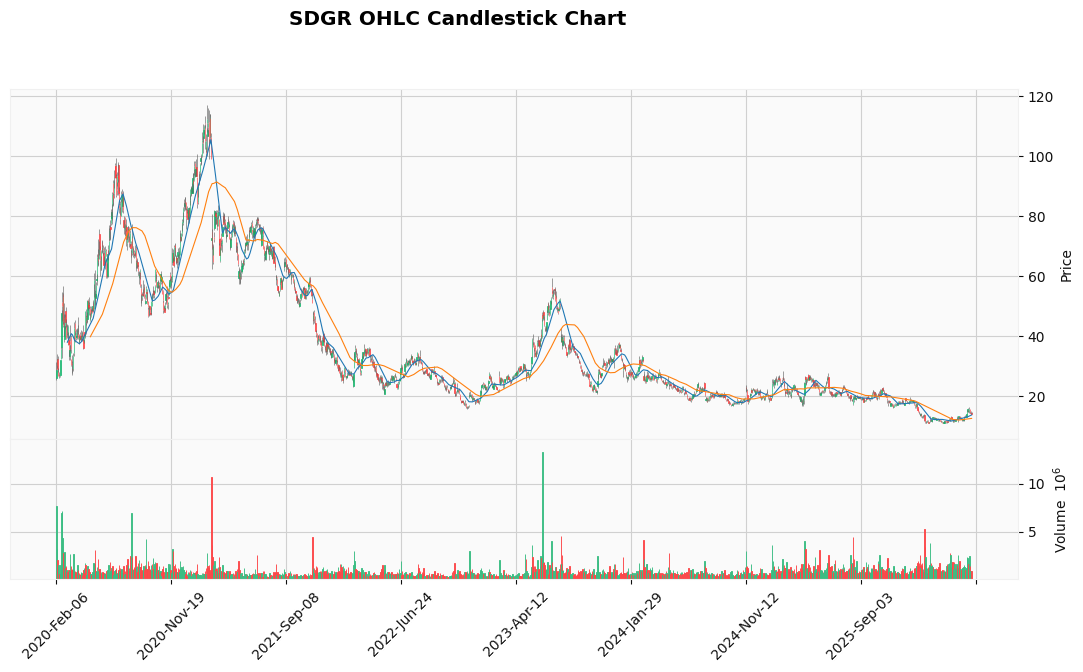

/Users/lol/Documents/GitHub/.venv/lib/python3.14/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


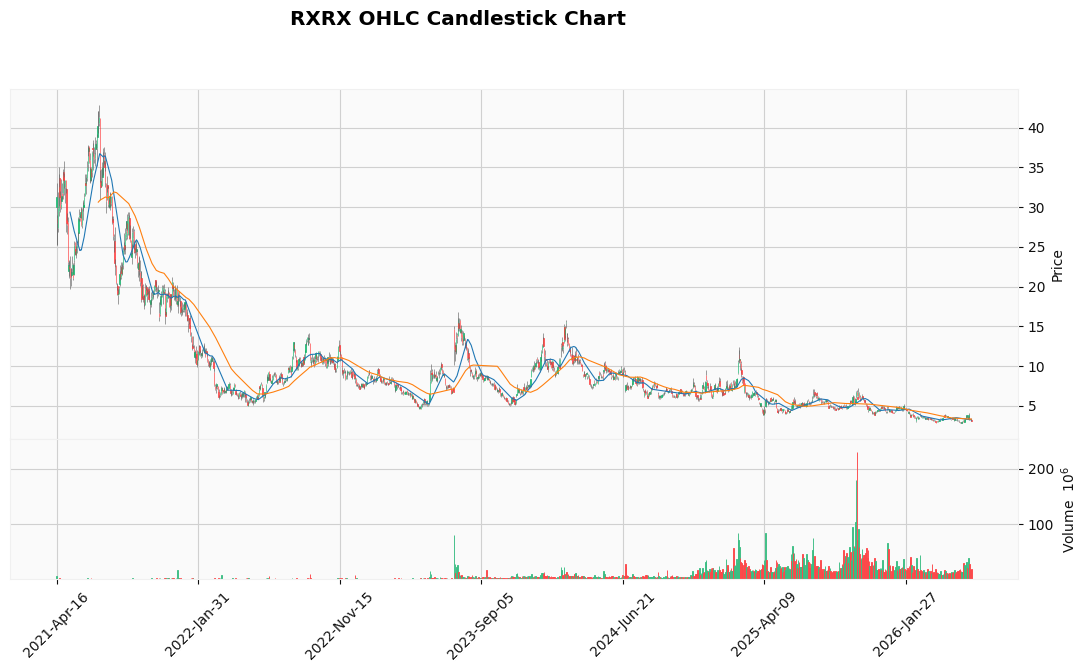

In [4]:
for ticker in tickers:
    ohlc = data[ticker][["Open", "High", "Low", "Close", "Volume"]].dropna()

    mpf.plot(
        ohlc,
        type="candle",          # 'ohlc'로 바꾸면 전통적인 OHLC bar chart
        volume=True,
        title=f"{ticker} OHLC Candlestick Chart",
        style="yahoo",
        figsize=(14, 7),
        mav=(20, 60)
    )

/Users/lol/Documents/GitHub/.venv/lib/python3.14/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


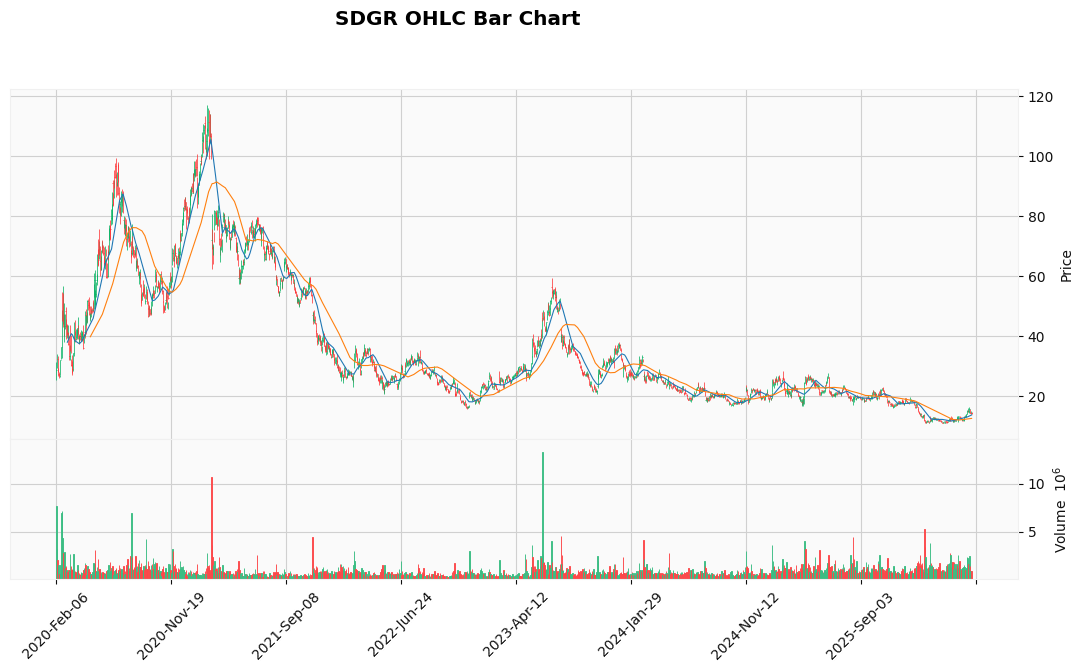

/Users/lol/Documents/GitHub/.venv/lib/python3.14/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


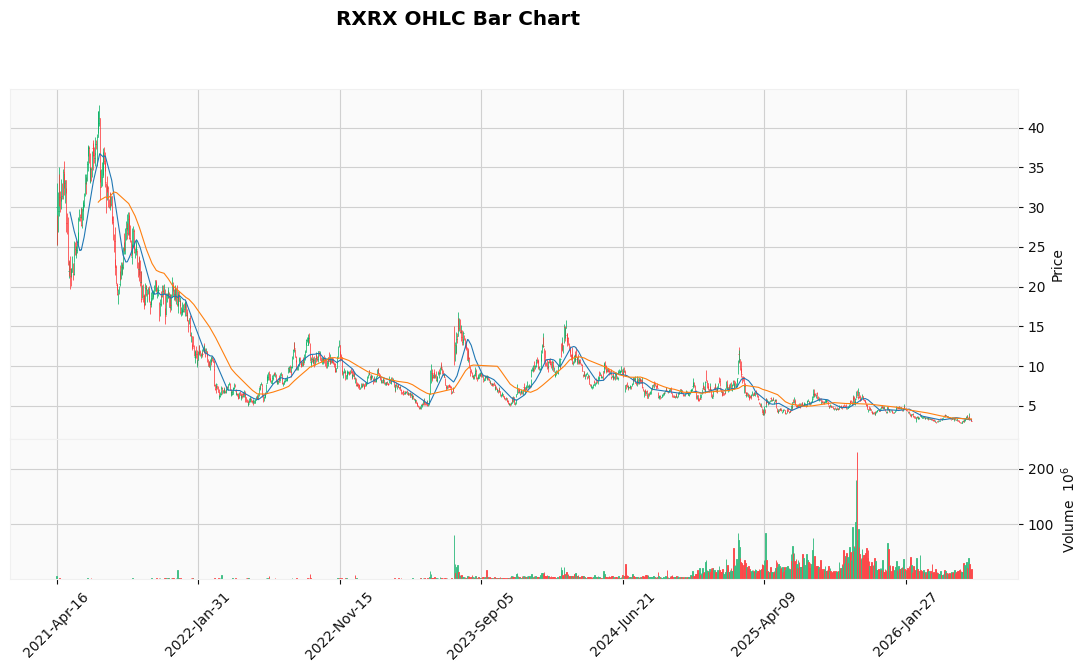

In [6]:
for ticker in tickers:
    ohlc = data[ticker][["Open", "High", "Low", "Close", "Volume"]].dropna()

    mpf.plot(
        ohlc,
        type="ohlc",
        volume=True,
        title=f"{ticker} OHLC Bar Chart",
        style="yahoo",
        figsize=(14, 7),
        mav=(20, 60)
    )

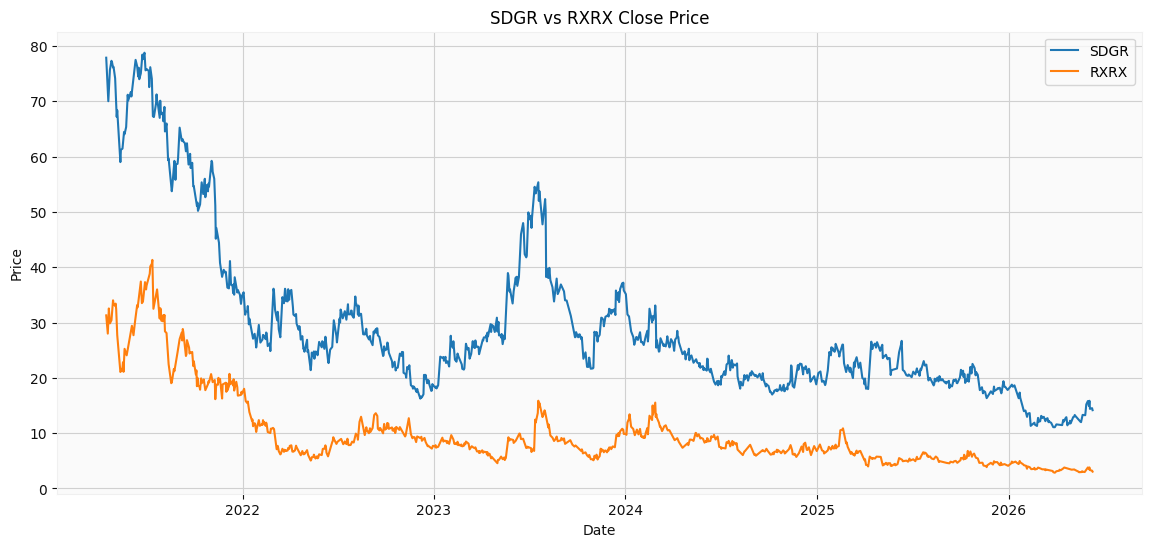

In [7]:
close = pd.concat(
    [data[ticker]["Close"].rename(ticker) for ticker in tickers],
    axis=1
).dropna()

plt.figure(figsize=(14, 6))
plt.plot(close.index, close["SDGR"], label="SDGR")
plt.plot(close.index, close["RXRX"], label="RXRX")

plt.title("SDGR vs RXRX Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

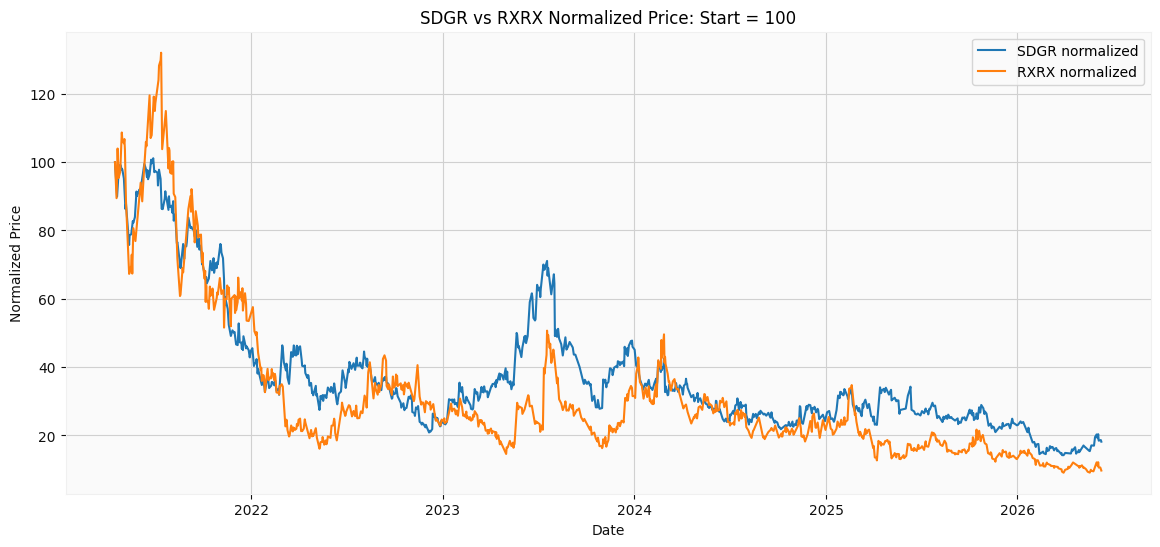

In [8]:
normalized = close / close.iloc[0] * 100

plt.figure(figsize=(14, 6))
plt.plot(normalized.index, normalized["SDGR"], label="SDGR normalized")
plt.plot(normalized.index, normalized["RXRX"], label="RXRX normalized")

plt.title("SDGR vs RXRX Normalized Price: Start = 100")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
log_returns = np.log(close / close.shift(1)).dropna()

log_returns.head()

,SDGR,RXRX
Date,,
2021-04-19,-0.071564,-0.111414
2021-04-20,-0.034939,0.066991
2021-04-21,0.033697,0.083582
2021-04-22,0.011394,-0.040758
2021-04-23,0.032499,-0.045835


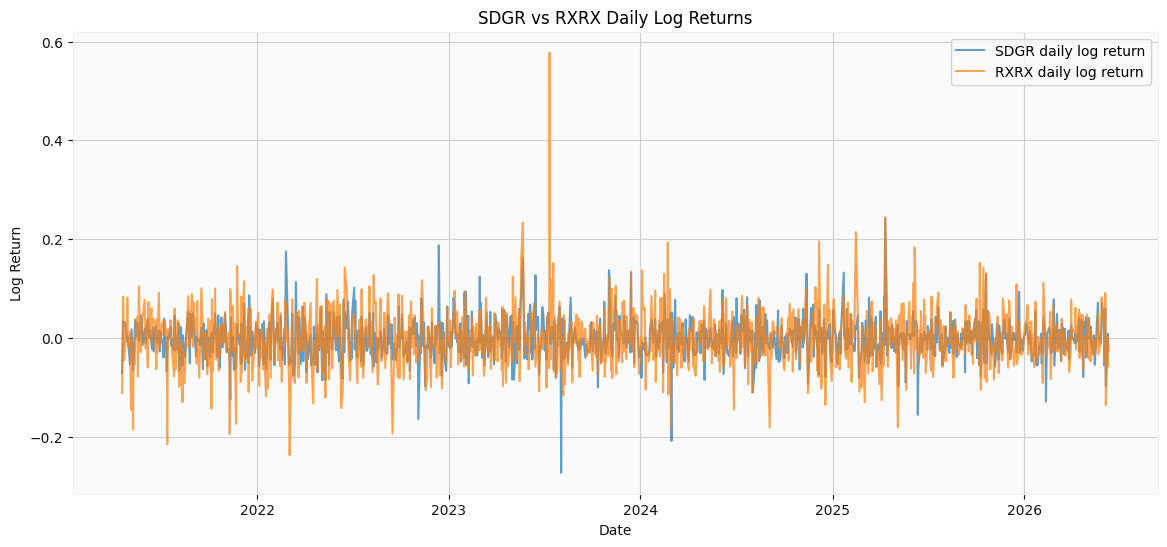

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(log_returns.index, log_returns["SDGR"], label="SDGR daily log return", alpha=0.7)
plt.plot(log_returns.index, log_returns["RXRX"], label="RXRX daily log return", alpha=0.7)

plt.title("SDGR vs RXRX Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
pearson_corr, pearson_p = pearsonr(log_returns["SDGR"], log_returns["RXRX"])
spearman_corr, spearman_p = spearmanr(log_returns["SDGR"], log_returns["RXRX"])

print(f"Pearson correlation:  {pearson_corr:.4f}, p-value: {pearson_p:.4g}")
print(f"Spearman correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4g}")

Pearson correlation:  0.5222, p-value: 2.32e-91
Spearman correlation: 0.5740, p-value: 3.301e-114


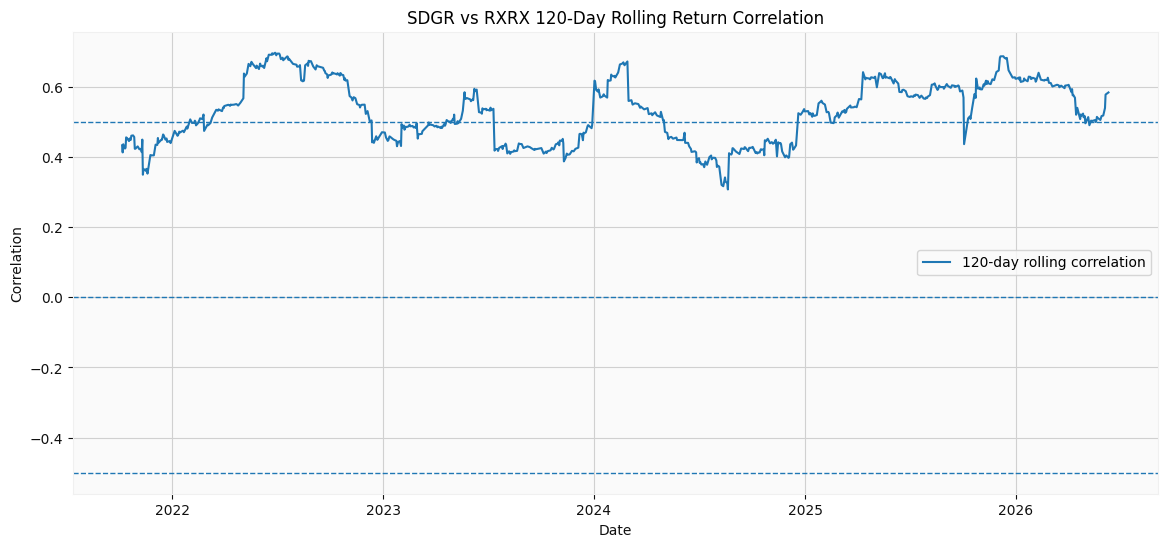

In [13]:
window = 120  # 60거래일, 약 3개월

rolling_corr = log_returns["SDGR"].rolling(window).corr(log_returns["RXRX"])

plt.figure(figsize=(14, 6))
plt.plot(rolling_corr.index, rolling_corr, label=f"{window}-day rolling correlation")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.axhline(-0.5, linestyle="--", linewidth=1)

plt.title(f"SDGR vs RXRX {window}-Day Rolling Return Correlation")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend()
plt.grid(True)
plt.show()

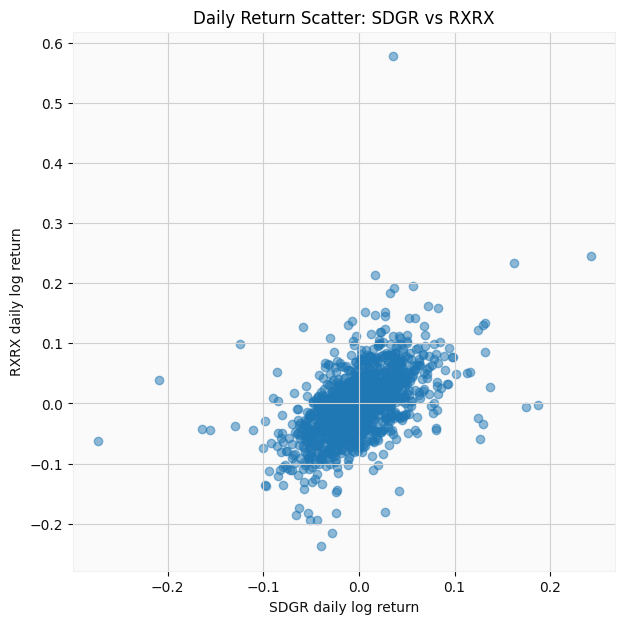

In [14]:
plt.figure(figsize=(7, 7))
plt.scatter(log_returns["SDGR"], log_returns["RXRX"], alpha=0.5)

plt.title("Daily Return Scatter: SDGR vs RXRX")
plt.xlabel("SDGR daily log return")
plt.ylabel("RXRX daily log return")
plt.grid(True)
plt.show()

In [15]:
X = log_returns["SDGR"]
y = log_returns["RXRX"]

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   RXRX   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.272
Method:                 Least Squares   F-statistic:                     484.0
Date:                Thu, 11 Jun 2026   Prob (F-statistic):           2.32e-91
Time:                        10:15:16   Log-Likelihood:                 2075.8
No. Observations:                1293   AIC:                            -4148.
Df Residuals:                    1291   BIC:                            -4137.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0008      0.001     -0.596      0.5

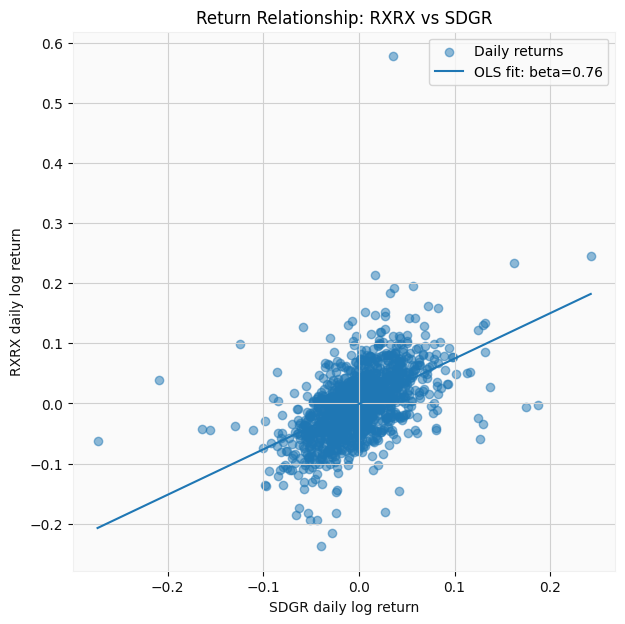

In [16]:
beta = model.params["SDGR"]
alpha = model.params["const"]

x_vals = np.linspace(log_returns["SDGR"].min(), log_returns["SDGR"].max(), 100)
y_vals = alpha + beta * x_vals

plt.figure(figsize=(7, 7))
plt.scatter(log_returns["SDGR"], log_returns["RXRX"], alpha=0.5, label="Daily returns")
plt.plot(x_vals, y_vals, label=f"OLS fit: beta={beta:.2f}")

plt.title("Return Relationship: RXRX vs SDGR")
plt.xlabel("SDGR daily log return")
plt.ylabel("RXRX daily log return")
plt.legend()
plt.grid(True)
plt.show()

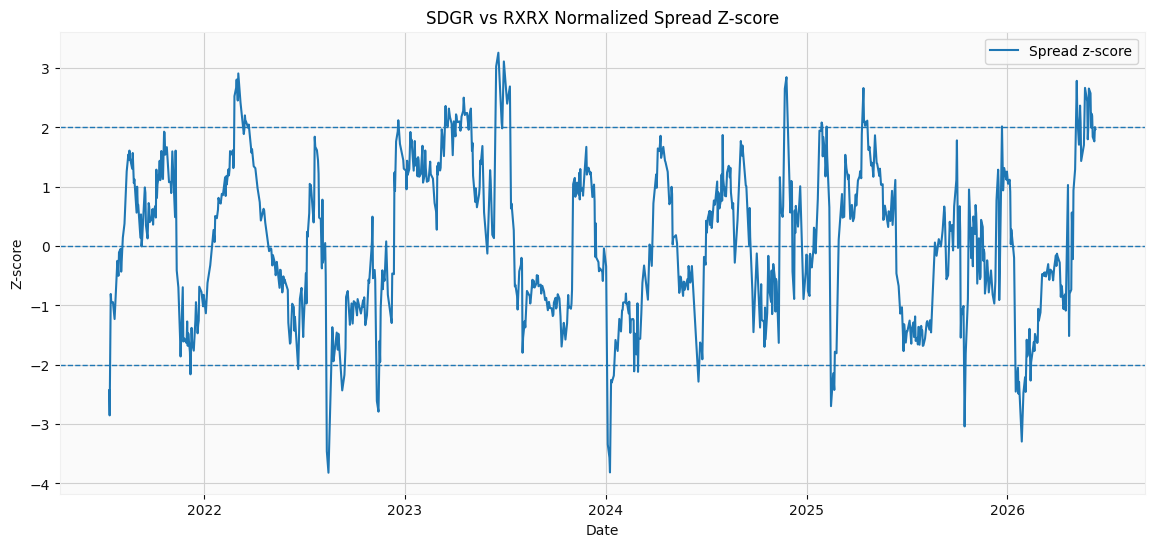

In [17]:
spread = normalized["SDGR"] - normalized["RXRX"]

zscore = (spread - spread.rolling(60).mean()) / spread.rolling(60).std()

plt.figure(figsize=(14, 6))
plt.plot(zscore.index, zscore, label="Spread z-score")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axhline(2, linestyle="--", linewidth=1)
plt.axhline(-2, linestyle="--", linewidth=1)

plt.title("SDGR vs RXRX Normalized Spread Z-score")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
score, pvalue, crit = coint(np.log(close["SDGR"]), np.log(close["RXRX"]))

print(f"Cointegration test statistic: {score:.4f}")
print(f"p-value: {pvalue:.4f}")
print("Critical values:", crit)

Cointegration test statistic: -3.3529
p-value: 0.0479
Critical values: [-3.9049302  -3.3408596  -3.04773175]


In [20]:
def dtw_distance(s1, s2):
    """
    간단한 DTW 거리 계산 함수.
    값이 낮을수록 두 시계열의 모양이 비슷함.
    """
    s1 = np.array(s1)
    s2 = np.array(s2)
    
    n, m = len(s1), len(s2)
    dtw = np.full((n + 1, m + 1), np.inf)
    dtw[0, 0] = 0
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(s1[i - 1] - s2[j - 1])
            dtw[i, j] = cost + min(
                dtw[i - 1, j],
                dtw[i, j - 1],
                dtw[i - 1, j - 1]
            )
    
    return dtw[n, m]

# 계산량을 줄이기 위해 월간 데이터로 변환
monthly_close = close.resample("ME").last().dropna()
monthly_norm = monthly_close / monthly_close.iloc[0] * 100

# 표준화
sdgr_std = (monthly_norm["SDGR"] - monthly_norm["SDGR"].mean()) / monthly_norm["SDGR"].std()
rxrx_std = (monthly_norm["RXRX"] - monthly_norm["RXRX"].mean()) / monthly_norm["RXRX"].std()

dtw_dist = dtw_distance(sdgr_std, rxrx_std)

print(f"Monthly normalized DTW distance: {dtw_dist:.4f}")

Monthly normalized DTW distance: 11.7663


In [21]:
benchmark_tickers = ["SDGR", "RXRX", "XBI", "IBB", "SPY"]

bench_data = yf.download(
    benchmark_tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)["Close"].dropna()

bench_returns = np.log(bench_data / bench_data.shift(1)).dropna()

corr_matrix = bench_returns.corr()

corr_matrix

Ticker,IBB,RXRX,SDGR,SPY,XBI
Ticker,,,,,
IBB,1.000000,0.543324,0.563624,0.661872,0.897038
RXRX,0.543324,1.000000,0.522202,0.431481,0.603070
SDGR,0.563624,0.522202,1.000000,0.439525,0.604381
SPY,0.661872,0.431481,0.439525,1.000000,0.604426
XBI,0.897038,0.603070,0.604381,0.604426,1.000000


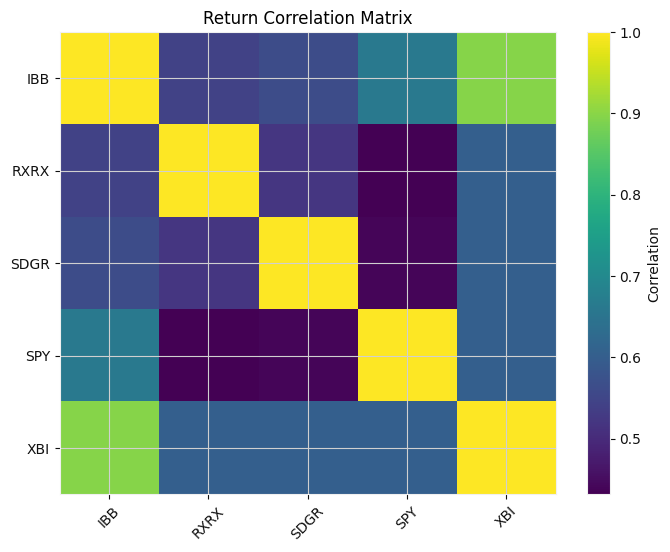

In [22]:
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

plt.title("Return Correlation Matrix")
plt.show()

In [23]:
summary = {}

summary["Pearson daily return corr"] = pearson_corr
summary["Spearman daily return corr"] = spearman_corr
summary["OLS beta: RXRX ~ SDGR"] = beta
summary["OLS alpha"] = alpha
summary["OLS R-squared"] = model.rsquared
summary["Cointegration p-value"] = pvalue
summary["Monthly DTW distance"] = dtw_dist
summary["Latest 60D rolling corr"] = rolling_corr.dropna().iloc[-1]
summary["Average 60D rolling corr"] = rolling_corr.mean()

summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])
summary_df

,Value
Pearson daily return corr,0.522202
Spearman daily return corr,0.574039
OLS beta: RXRX ~ SDGR,0.755245
OLS alpha,-0.000807
OLS R-squared,0.272695
Cointegration p-value,0.047852
Monthly DTW distance,11.766323
Latest 60D rolling corr,0.584165
Average 60D rolling corr,0.527042


In [1]:
# 벤치마크 대비 상관 비교
targets = ["SDGR", "RXRX", "XBI", "IBB", "SPY", "QQQ", "ARKG"]

bench = yf.download(
    targets,
    start="2020-01-01",
    auto_adjust=True,
    progress=False
)["Close"].dropna()

bench_ret = np.log(bench / bench.shift(1)).dropna()

corr = bench_ret.corr()
corr.loc[["SDGR", "RXRX"], :]

NameError: name 'yf' is not defined